This file is based on the reference:
Rajandran R 
Introduction to Backtrader – Creating your First Trading Strategy – Python Trading Tutorial
September 25, 2024
https://www.marketcalls.in/python/introduction-to-backtrader-creating-your-first-trading-strategy-python-trading-tutorial.html

In this example, it will implement a simple Exponential Moving Average (EMA) crossover strategy using two EMAs (10-day and 20-day). 
The strategy works as follows:

Buy when the 10-day EMA crosses above the 20-day EMA.
Sell when the 10-day EMA crosses below the 20-day EMA.

We will test this strategy using RELIANCE.NS data from Yahoo Finance, set an initial capital of ₹3,00,000, and apply a trading commission of 0.002%

In [14]:
import backtrader as bt
import datetime
import yfinance as yf
import matplotlib.pyplot as plt

In [15]:
# Fetch data using yfinance
data_df = yf.download('RELIANCE.NS', start='2020-01-01', end='2023-01-01')

[*********************100%***********************]  1 of 1 completed


In [16]:
data_df

Price,Close,High,Low,Open,Volume
Ticker,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS,RELIANCE.NS
Date,,,,,
2020-01-01,680.385132,688.272495,678.537292,684.171071,14004468
2020-01-02,691.968262,694.514766,681.466821,681.466821,17710316
2020-01-03,692.802124,694.830302,686.424611,690.931659,20984698
2020-01-06,676.734436,688.633025,675.156951,685.072492,24519177
2020-01-07,687.145752,691.607730,682.142882,684.621752,16683622
...,...,...,...,...,...
2022-12-26,1156.822021,1165.048875,1142.316225,1152.559725,5990242
2022-12-27,1166.286499,1168.165551,1152.788964,1159.549188,5763271


In [17]:
data_df.columns = [col[0] for col in data_df.columns]  # Takes 'Close', 'High', 'Low', 'Open', 'Volume'
data_df

,Close,High,Low,Open,Volume
Date,,,,,
2020-01-01,680.385132,688.272495,678.537292,684.171071,14004468
2020-01-02,691.968262,694.514766,681.466821,681.466821,17710316
2020-01-03,692.802124,694.830302,686.424611,690.931659,20984698
2020-01-06,676.734436,688.633025,675.156951,685.072492,24519177
2020-01-07,687.145752,691.607730,682.142882,684.621752,16683622
...,...,...,...,...,...
2022-12-26,1156.822021,1165.048875,1142.316225,1152.559725,5990242
2022-12-27,1166.286499,1168.165551,1152.788964,1159.549188,5763271
2022-12-28,1166.171875,1168.623856,1155.653426,1163.215702,7459393


In [18]:
# Create a custom pandas feed to use with Backtrader
class PandasData(bt.feeds.PandasData):
    params = (
        ('fromdate', datetime.datetime(2020, 1, 1)),
        ('todate', datetime.datetime(2023, 1, 1)),
        ('open', 'Open'),
        ('high', 'High'),
        ('low', 'Low'),
        ('close', 'Close'),
        ('volume', 'Volume'),
        ('openinterest', None),  # No open interest in Yahoo data
    )

In [19]:

# Define the EMA Crossover Strategy
class EmaCrossStrategy(bt.Strategy):
    params = (('short_period', 10), ('long_period', 20),)

    def __init__(self):
        # Initialize the 10-day and 20-day EMA indicators
        self.ema_short = bt.indicators.EMA(self.data.close, period=self.params.short_period)
        self.ema_long = bt.indicators.EMA(self.data.close, period=self.params.long_period)
        self.trade_list = []  # To keep track of trades

    def next(self):
        if not self.position:  # Check if we are not in a position
            if self.ema_short > self.ema_long:  # Buy if short EMA crosses above long EMA
                self.buy()
        else:
            if self.ema_short < self.ema_long:  # Sell if short EMA crosses below long EMA
                self.sell()

    def notify_trade(self, trade):
        if trade.isclosed:
            exit_price = None
            if trade.size != 0:
                exit_price = trade.price + trade.pnlcomm / trade.size  # Calculate exit price
            else:
                exit_price = trade.price  # Set exit price to entry price if size is zero (or handle as needed)

            # Log the trade details when a trade is closed
            trade_details = {
                'Entry Price': trade.price,  # Entry price of the trade
                'Exit Price': exit_price,  # Calculated exit price
                'Size': trade.size,  # Size of the trade
                'Profit/Loss': trade.pnlcomm  # Net PnL after commission
            }
            self.trade_list.append(trade_details)


    def notify_order(self, order):
        if order.status in [order.Completed]:
            if order.isbuy():
                print(f"Buy Executed: Price: {order.executed.price}, Size: {order.executed.size}")
            elif order.issell():
                print(f"Sell Executed: Price: {order.executed.price}, Size: {order.executed.size}")
        elif order.status in [order.Canceled, order.Margin, order.Rejected]:
            print("Order Failed")

    def stop(self):
        # Print list of trades
        print("List of Trades:")
        for trade in self.trade_list:
            print(trade)
        print("\n")



In [20]:
# Create an instance of Cerebro engine
cerebro = bt.Cerebro()

# Add the strategy to Cerebro
cerebro.addstrategy(EmaCrossStrategy)

# Convert the DataFrame into a Backtrader-compatible data feed
data_feed = PandasData(dataname=data_df)

# Add the data feed to Cerebro
cerebro.adddata(data_feed)

# Set initial capital and commissions
cerebro.broker.setcash(300000)  # Rs 3,00,000 starting capital
cerebro.broker.setcommission(commission=0.002 / 100)  # 0.002% commission on turnover

In [21]:
# Print the starting portfolio value
print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())

Starting Portfolio Value: 300000.00


In [22]:
# Run the backtest

results = cerebro.run()

Buy Executed: Price: 539.5170716188857, Size: 1
Sell Executed: Price: 995.4310510096993, Size: -1
Buy Executed: Price: 917.2903384116108, Size: 1
Sell Executed: Price: 908.1766247221133, Size: -1
Buy Executed: Price: 910.6891794120396, Size: 1
Sell Executed: Price: 877.3406691219659, Size: -1
Buy Executed: Price: 923.4347645577311, Size: 1
Sell Executed: Price: 865.3716456032956, Size: -1
Buy Executed: Price: 939.0126553328489, Size: 1
Sell Executed: Price: 941.9591760895053, Size: -1
Buy Executed: Price: 912.6991863404032, Size: 1
Sell Executed: Price: 957.6283525313654, Size: -1
Buy Executed: Price: 967.2446534585326, Size: 1
Sell Executed: Price: 1144.8370418730785, Size: -1
Buy Executed: Price: 1119.7800725052634, Size: 1
Sell Executed: Price: 1080.4012055208775, Size: -1
Buy Executed: Price: 1101.8721976565464, Size: 1
Sell Executed: Price: 1052.991409674357, Size: -1
Buy Executed: Price: 1111.3515469423237, Size: 1
Sell Executed: Price: 1129.578931172324, Size: -1
Buy Executed: P

In [23]:


# Print the starting portfolio value
print('Starting Portfolio Value: %.2f' % cerebro.broker.getvalue())

# Print the final portfolio value
final_value = cerebro.broker.getvalue()
print('Final Portfolio Value: %.2f' % final_value)

# Calculate Profit/Loss and other metrics
profit_loss = final_value - 300000
print('Net Profit/Loss: %.2f' % profit_loss)

# Plot the results
fig = cerebro.plot(iplot=False)[0][0]
plt.show()


Starting Portfolio Value: 300519.36
Final Portfolio Value: 300519.36
Net Profit/Loss: 519.36


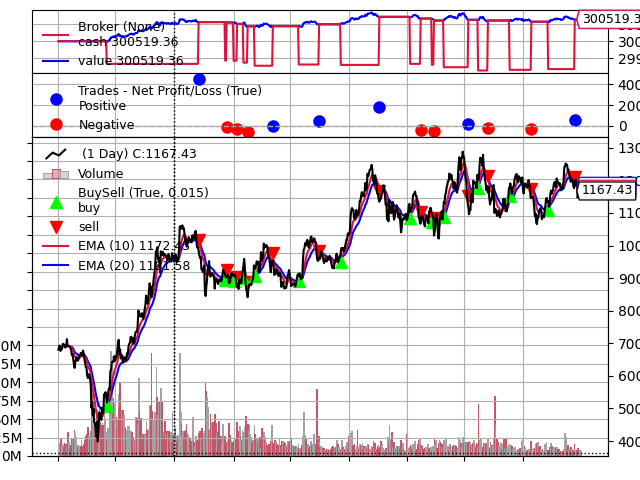

In [24]:
from IPython.display import Image

Image(filename=r"Documents\8_Backtrader.png")